In [ ]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
import matplotlib as mpl
pd.options.mode.chained_assignment = None


eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_p2d/"
res_DIR = "../data/results_p2d/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [ ]:
with open('dfn_sim_sei_c5_eSOH.pickle', 'rb') as handle:
        (x_100_a,y_100_a,x_0_a,y_0_a,n_Li_a,delta_sei_a,Cp,Cn) = pickle.load(handle)
with open('spm_sim_sei_c5_eSOH.pickle', 'rb') as handle:
        all_sumvars_dict = pickle.load(handle)


In [ ]:
y_100_a[0] = all_sumvars_dict["y_100"][0]
Cap = Cn*(np.array(x_100_a)-np.array(x_0_a))

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
ax.plot(range(1,len(n_Li_a)+1),Cap)
ax.plot(all_sumvars_dict["Cycle number"],all_sumvars_dict["C"],'--')
ax.set_xlabel("Cycle Number")
ax.set_ylabel("Capacity [Ah]")
ax.set_title("Capacity")
fig.savefig(fig_DIR+"multi_cycle_comp_sei_vars_0.png")

In [ ]:
(all_sumvars_dict["C"][-1]-Cap[-1])*100/all_sumvars_dict["C"][-1]

In [ ]:
(all_sumvars_dict["n_Li"][-1]-n_Li_a[-1])*100/all_sumvars_dict["n_Li"][-1]
(all_sumvars_dict["X-averaged SEI thickness [m]"][-1]-delta_sei_a[-1])*100/all_sumvars_dict["X-averaged SEI thickness [m]"][-1]

In [ ]:
fig,ax = plt.subplots(2,1,figsize=(5,8))
ax1 = ax.flat[0]
ax1.plot(range(1,len(n_Li_a)+1),n_Li_a)
ax1.plot(all_sumvars_dict["Cycle number"],all_sumvars_dict["n_Li"],'--')
ax1.set_xlabel("Cycle Number")
ax1.set_title("Number of Moles of Li")
ax1.set_ylabel("Number of Moles of Li [mol]")
ax1.legend(["DFN","SPM"])
ax2 = ax.flat[1]
ax2.plot(range(1,len(n_Li_a)+1),delta_sei_a)
ax2.plot(all_sumvars_dict["Cycle number"],all_sumvars_dict["X-averaged SEI thickness [m]"],'--')
ax2.set_xlabel("Cycle Number")
ax2.set_title("Thickenss of SEI Layer")
ax2.set_ylabel("Thickenss of SEI Layer [m]")
# fig.suptitle("C/5 SEI Only Comparison")
fig.tight_layout()
fig.savefig(fig_DIR+"multi_cycle_comp_sei_vars_1.png")

In [ ]:
len(x_0_a)

In [ ]:
fig,ax = plt.subplots(2,2,figsize=(10,8))
ax1 = ax.flat[0]
ax1.plot(range(1,len(n_Li_a)+1),x_0_a)
ax1.plot(all_sumvars_dict["Cycle number"],all_sumvars_dict["x_0"],'--')
ax1.set_title(r"x_0")
ax1.legend(["DFN","SPM"])
ax2 = ax.flat[1]
ax2.plot(range(1,len(n_Li_a)+1),y_0_a)
ax2.plot(all_sumvars_dict["Cycle number"],all_sumvars_dict["y_0"],'--')
ax2.set_title(r"y_0")
# ax2.set_xlabel("Cycle Number")
ax3 = ax.flat[2]
ax3.plot(range(1,len(n_Li_a)+1),x_100_a)
ax3.plot(all_sumvars_dict["Cycle number"],all_sumvars_dict["x_100"],'--')
ax3.set_title(r"x_100")
ax3.set_xlabel("Cycle Number")
ax4 = ax.flat[3]
ax4.plot(range(1,len(n_Li_a)+1),y_100_a)
ax4.plot(all_sumvars_dict["Cycle number"],all_sumvars_dict["y_100"],'--')
ax4.set_title(r"y_100")
ax4.set_xlabel("Cycle Number")
fig.suptitle("C/5 SEI Only Comparison")
fig.savefig(fig_DIR+"multi_cycle_comp_sei_vars_2.png")

## V2

In [68]:
with open('dfn_sim_sei_c5_eSOH.pickle', 'rb') as handle:
        (x_100_a,y_100_a,x_0_a,y_0_a,n_Li_a,delta_sei_a,Cp,Cn,time_a,Qmax_a,Ahth_a) = pickle.load(handle)
with open('spm_sim_sei_c5_eSOH_V2.pickle', 'rb') as handle:
        (x_100_a_spm,y_100_a_spm,x_0_a_spm,y_0_a_spm,n_Li_a_spm,delta_sei_a_spm,C_a_spm,time_a_spm,Qmax_a_spm,Ahth_a_spm) = pickle.load(handle)


In [69]:
C_a = Cn*(np.array(x_100_a)-np.array(x_0_a))
t_a = np.array(time_a)
t_a = t_a/3600/24
t_a_spm = np.array(time_a_spm)
t_a_spm = t_a_spm/3600/24

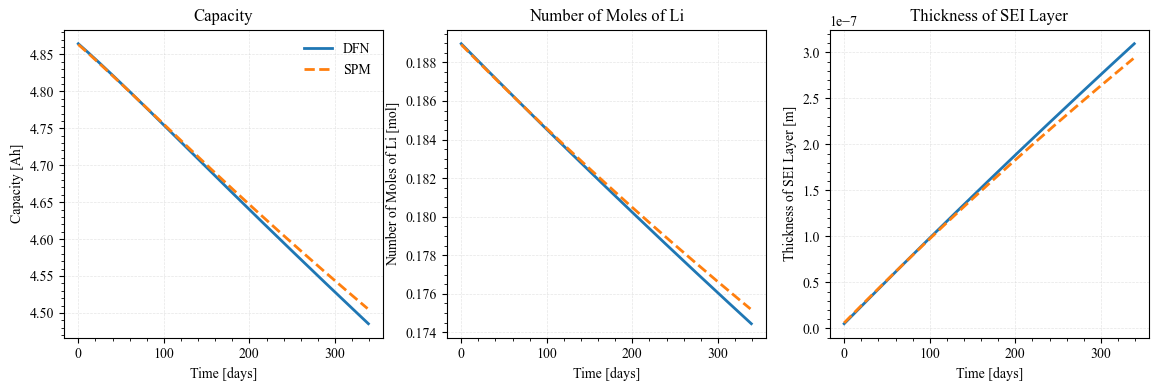

In [73]:
fig,ax = plt.subplots(1,3,figsize=(14,4))
ax1 = ax.flat[0]
ax1.plot(range(len(t_a)),C_a)
ax1.plot(range(len(t_a_spm)),C_a_spm,'--')
ax1.set_xlabel("Time [days]")
ax1.set_ylabel("Capacity [Ah]")
ax1.set_title("Capacity")
ax1.legend(["DFN","SPM"])
ax2 = ax.flat[1]
ax2.plot(range(len(t_a)),n_Li_a)
ax2.plot(range(len(t_a_spm)),n_Li_a_spm,'--')
ax2.set_xlabel("Time [days]")
ax2.set_title("Number of Moles of Li")
ax2.set_ylabel("Number of Moles of Li [mol]")
ax3 = ax.flat[2]
ax3.plot(range(len(t_a)),delta_sei_a)
ax3.plot(range(len(t_a_spm)),delta_sei_a_spm,'--')
ax3.set_xlabel("Time [days]")
ax3.set_title("Thickness of SEI Layer")
ax3.set_ylabel("Thickness of SEI Layer [m]")
fig.savefig(fig_DIR+"multi_cycle_comp_sei_vars_1.png")